# **Sección 1. Datos, limpieza y análisis exploratorio de datos**

## **1.1 Contexto del problema**

El término **churn** o **fuga de clientes**, hace referencia al fenómeno mediante el cual un cliente termina su relación contractual con una empresa. En el sector de telecomunicaciones, donde los servicios suelen ofrecerse bajo modalidades de suscripción mensual o anual, el churn representa una de las principales preocupaciones operacionales y financieras: es ampliamente aceptado en la literatura de marketing que **adquirir un nuevo cliente cuesta varias veces más que retener uno existente**, y que pequeñas variaciones en la tasa de retención pueden tener efectos significativos sobre los ingresos a largo plazo.

Predecir el churn de manera anticipada permite a la empresa:

- Identificar segmentos de clientes con alta probabilidad de cancelar el servicio.
- Diseñar campañas de retención focalizadas (descuentos, mejoras de plan, atención personalizada).
- Detectar problemas estructurales en ciertos tipos de contrato, métodos de pago o servicios contratados.

Desde una perspectiva de ciencia de datos, se trata de un **problema de clasificación binaria supervisada**, donde la variable objetivo es `Churn` (`Yes` / `No`). El dataset utilizado contiene información demográfica del cliente, características del contrato, servicios contratados y montos de facturación, lo que lo hace especialmente adecuado para explorar la relación entre las decisiones comerciales del cliente y su propensión a abandonar la empresa.


## **1.2 Importación de librerías**

Para el desarrollo del análisis se utilizan las librerías estándar del ecosistema científico de Python: `pandas` y `numpy` para la manipulación de datos, `matplotlib` y `seaborn` para la visualización, y los módulos de `scikit-learn` correspondientes a preprocesamiento, *pipelines* y partición de datos.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import joblib

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Manejo de advertencias y formato
import warnings
warnings.filterwarnings("ignore")

# Configuración estética para los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# Paleta de colores institucional para coherencia visual a lo largo del notebook
azul    = "#457b9d"   # clase No churn
rojo    = "#e63946"   # clase Yes churn
neutro  = "#a8dadc"
colors  = [azul, rojo]

# Configuración de pandas para mejor visualización de tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## **1.3 Carga del dataset**

El conjunto de datos se carga directamente desde el archivo CSV original distribuido por Kaggle. Se asume una estructura de carpetas en la que el archivo se encuentra en `../data/telco_churn.csv` relativo al notebook. Esta convención facilita la reproducibilidad y mantiene el código compatible con la organización del repositorio del proyecto.

In [2]:
# Carga del dataset desde el archivo CSV original
df = pd.read_csv("../data/telco_churn.csv")

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado correctamente.
Dimensiones: 7043 filas x 21 columnas


## **1.4 Exploración inicial del dataset**

Antes de cualquier transformación es necesario observar la estructura general del *DataFrame*: el tipo de cada variable, los rangos de las numéricas, la cardinalidad de las categóricas y la forma en que está codificada la variable objetivo. Esta inspección preliminar permite anticipar problemas (tipos incorrectos, valores codificados como texto, inconsistencias) que luego deberán tratarse en la etapa de limpieza.

### **1.4.1 Primeras y últimas observaciones**

In [3]:
# Primeras observaciones
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Últimas observaciones
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


La inspección visual de las primeras y últimas filas confirma que el archivo se cargó correctamente y que el separador es coherente. Cada fila representa un cliente único, identificado mediante la columna `customerID`. Se observan variables de naturaleza heterogénea: identificadores, atributos demográficos, indicadores de servicios contratados y variables de facturación. Llama la atención que columnas como `TotalCharges`, que conceptualmente debería ser numérica, aparecen con un formato que se examinará con más detalle más adelante.

### **1.4.2 Dimensiones, columnas y tipos de datos**

In [5]:
# Dimensiones
print("Dimensiones del dataset:", df.shape)
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables:     {df.shape[1]}")

Dimensiones del dataset: (7043, 21)
Número de observaciones: 7043
Número de variables:     21


In [6]:
# Listado de columnas
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
# Información estructural y completitud por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset cuenta con **7 043 observaciones y 21 columnas**, lo cual constituye un volumen suficiente para un proyecto de clasificación binaria sin requerir técnicas avanzadas de manejo de grandes datos. La salida de `df.info()` revela una distribución mixta de tipos de datos:

- **Variables numéricas (`int64`, `float64`)**: `SeniorCitizen`, `tenure` y `MonthlyCharges`.
- **Variables tipo `object` (texto)**: el resto de las columnas, que incluyen tanto variables genuinamente categóricas (como `Contract` o `PaymentMethod`) como variables que conceptualmente son numéricas pero se almacenaron como texto (caso de `TotalCharges`).

Adicionalmente, en una primera lectura `df.info()` reporta que ninguna columna tiene valores nulos explícitos. Sin embargo, esto puede ser engañoso: como se verá más adelante, la columna `TotalCharges` contiene cadenas vacías que pandas no detecta como `NaN` y que requerirán un tratamiento específico. Este es un hallazgo característico del dataset Telco que debe abordarse con cuidado para no introducir sesgos en el modelado.

### **1.4.3 Estadísticos descriptivos**

In [8]:
# Resumen estadístico de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


El resumen de las variables numéricas evidencia tres comportamientos distintos:

- **`SeniorCitizen`** es una variable binaria codificada como entero (0/1), con una media cercana a 0.16, lo que sugiere que aproximadamente el **16% de los clientes son adultos mayores**. Sus valores están restringidos a {0, 1}, por lo que más adelante será tratada como categórica binaria.
- **`tenure`** representa la antigüedad del cliente en meses y oscila entre 0 y 72, con una media cercana a 32 meses y una mediana de 29. La presencia de valores en 0 corresponde a clientes muy nuevos que aún no completan su primer ciclo de facturación, un detalle relevante que se retomará al analizar `TotalCharges`.
- **`MonthlyCharges`** se distribuye entre 18.25 y 118.75 dólares, con una media de aproximadamente 64.76. La amplia variabilidad refleja la diversidad de planes contratados.

In [9]:
# Resumen estadístico de variables categóricas
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Para las variables tipo `object`, `describe` reporta el conteo de valores no nulos, el número de categorías únicas (`unique`), el valor más frecuente (`top`) y su frecuencia (`freq`). De esta inspección se desprenden varias observaciones:

- La variable `customerID` tiene **7 043 valores únicos**, exactamente el número de filas. Esto confirma que se trata de un identificador y no aporta valor predictivo.
- La variable `gender` cuenta con dos categorías (`Male`, `Female`) en proporciones similares.
- La variable objetivo `Churn` tiene dos categorías (`Yes`, `No`), con `No` como categoría predominante. Esto anticipa cierto desbalance que se cuantificará más adelante.
- Variables como `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` y `StreamingMovies` muestran tres categorías porque incluyen un valor adicional (`No internet service` o `No phone service`) que indica que el cliente no tiene contratado el servicio principal del que dependen.

### **1.4.4 Identificación de la variable objetivo**

La variable objetivo del problema es **`Churn`**, que indica si el cliente abandonó (`Yes`) o no (`No`) el servicio durante el último mes registrado. Se trata de una variable categórica dicotómica que será transformada a binaria numérica (1/0) para facilitar el modelado.

## **1.5 Diccionario preliminar de variables**

A continuación se presenta el diccionario de variables del dataset, que clasifica cada columna según su rol (identificador, predictor, objetivo) y su naturaleza estadística (numérica continua, numérica discreta, categórica nominal, binaria). Esta clasificación servirá de referencia para todas las decisiones de preprocesamiento posteriores.

In [10]:
# Diccionario de variables del dataset
diccionario = pd.DataFrame({
    "Variable": [
        "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
        "tenure", "PhoneService", "MultipleLines", "InternetService",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
        "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"
    ],
    "Rol": [
        "Identificador", "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Variable objetivo"
    ],
    "Tipo": [
        "Identificador", "Categórica binaria", "Categórica binaria",
        "Categórica binaria", "Categórica binaria",
        "Numérica discreta", "Categórica binaria", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica binaria",
        "Categórica nominal", "Numérica continua", "Numérica continua",
        "Categórica binaria"
    ],
    "Grupo conceptual": [
        "ID", "Demográfico", "Demográfico", "Demográfico", "Demográfico",
        "Antigüedad", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Facturación / Contrato", "Facturación / Contrato",
        "Facturación / Contrato", "Facturación", "Facturación",
        "Objetivo"
    ],
    "Descripción": [
        "Identificador único del cliente.",
        "Género del cliente (Male / Female).",
        "Indica si el cliente es adulto mayor (1) o no (0).",
        "Indica si el cliente tiene pareja (Yes / No).",
        "Indica si el cliente tiene dependientes a cargo (Yes / No).",
        "Antigüedad del cliente medida en meses.",
        "Indica si el cliente tiene servicio telefónico (Yes / No).",
        "Indica si tiene múltiples líneas telefónicas (Yes / No / No phone service).",
        "Tipo de servicio de internet (DSL / Fiber optic / No).",
        "Indica si tiene seguridad en línea contratada.",
        "Indica si tiene servicio de respaldo en línea.",
        "Indica si tiene protección de dispositivos.",
        "Indica si tiene soporte técnico contratado.",
        "Indica si tiene servicio de TV en streaming.",
        "Indica si tiene servicio de películas en streaming.",
        "Tipo de contrato (Month-to-month / One year / Two year).",
        "Indica si el cliente recibe facturación electrónica (Yes / No).",
        "Método de pago utilizado (cheque, tarjeta, transferencia, etc.).",
        "Cargo mensual facturado al cliente (en USD).",
        "Cargo total acumulado por el cliente (en USD).",
        "Indica si el cliente abandonó el servicio (Yes / No)."
    ]
})

pd.set_option("display.max_colwidth", None)
diccionario

,Variable,Rol,Tipo,Grupo conceptual,Descripción
0,customerID,Identificador,Identificador,ID,Identificador único del cliente.
1,gender,Predictor,Categórica binaria,Demográfico,Género del cliente (Male / Female).
2,SeniorCitizen,Predictor,Categórica binaria,Demográfico,Indica si el cliente es adulto mayor (1) o no (0).
3,Partner,Predictor,Categórica binaria,Demográfico,Indica si el cliente tiene pareja (Yes / No).
4,Dependents,Predictor,Categórica binaria,Demográfico,Indica si el cliente tiene dependientes a cargo (Yes / No).
5,tenure,Predictor,Numérica discreta,Antigüedad,Antigüedad del cliente medida en meses.
6,PhoneService,Predictor,Categórica binaria,Servicio contratado,Indica si el cliente tiene servicio telefónico (Yes / No).
7,MultipleLines,Predictor,Categórica nominal,Servicio contratado,Indica si tiene múltiples líneas telefónicas (Yes / No / No phone service).
8,InternetService,Predictor,Categórica nominal,Servicio contratado,Tipo de servicio de internet (DSL / Fiber optic / No).
9,OnlineSecurity,Predictor,Categórica nominal,Servicio contratado,Indica si tiene seguridad en línea contratada.


La tabla anterior agrupa las variables en cinco categorías conceptuales:

- **Demográficas**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`. Describen al cliente como persona.
- **Antigüedad**: `tenure`. Mide el tiempo de permanencia y suele ser un predictor fuerte del churn.
- **Servicios contratados**: desde `PhoneService` hasta `StreamingMovies`. Describen el portafolio de servicios que el cliente consume.
- **Facturación y contrato**: `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`. Capturan la relación económica con la empresa.
- **Objetivo**: `Churn`. La variable a predecir.

Esta clasificación inicial guiará tanto el análisis exploratorio como la definición del preprocesador.

## **1.6 Revisión de calidad de datos**

En esta etapa se examina la calidad del conjunto de datos antes de aplicar cualquier transformación. Se verifican duplicados, valores nulos, valores únicos por columna y se atiende con especial detalle el caso conocido de la variable `TotalCharges`, que en este dataset suele almacenarse como texto y contener espacios en blanco.

### **1.6.1 Verificación de duplicados**

In [11]:
# Verificación de filas duplicadas
duplicados_total = df.duplicated().sum()
duplicados_id    = df["customerID"].duplicated().sum()

print(f"Número de filas completamente duplicadas: {duplicados_total}")
print(f"Número de customerID duplicados:          {duplicados_id}")

Número de filas completamente duplicadas: 0
Número de customerID duplicados:          0


El conjunto de datos **no contiene filas duplicadas** ni identificadores repetidos. Esto es coherente con la naturaleza del dataset, donde cada fila representa a un cliente distinto. La ausencia de duplicados garantiza que ninguna observación contribuirá de forma desproporcionada al entrenamiento.

### **1.6.2 Valores nulos**

In [12]:
# Conteo y porcentaje de valores faltantes por columna
nulos = df.isnull().sum()
porcentaje = (df.isnull().mean() * 100).round(2)

tabla_nulos = pd.DataFrame({
    "Valores faltantes": nulos,
    "Porcentaje (%)":    porcentaje
}).rename_axis("Variable").reset_index()

tabla_nulos

,Variable,Valores faltantes,Porcentaje (%)
0,customerID,0,0.0
1,gender,0,0.0
2,SeniorCitizen,0,0.0
3,Partner,0,0.0
4,Dependents,0,0.0
5,tenure,0,0.0
6,PhoneService,0,0.0
7,MultipleLines,0,0.0
8,InternetService,0,0.0
9,OnlineSecurity,0,0.0


A primera vista, `pandas.isnull()` no detecta valores faltantes en ninguna columna. No obstante, este resultado debe interpretarse con cautela: al estar la variable `TotalCharges` almacenada como texto, las cadenas vacías o con espacios en blanco no son contabilizadas como `NaN`. Esto motiva un análisis más cuidadoso en las secciones siguientes.

### **1.6.3 Valores únicos por columna**

In [13]:
# Cantidad de valores únicos por columna
unicos = pd.DataFrame({
    "Variable":             df.columns,
    "Valores únicos":       df.nunique().values,
    "Tipo de dato":         df.dtypes.astype(str).values
})
unicos = unicos.sort_values("Valores únicos").reset_index(drop=True)
unicos

,Variable,Valores únicos,Tipo de dato
0,Churn,2,object
1,gender,2,object
2,SeniorCitizen,2,int64
3,Partner,2,object
4,Dependents,2,object
5,PaperlessBilling,2,object
6,PhoneService,2,object
7,Contract,3,object
8,StreamingMovies,3,object
9,StreamingTV,3,object


La cantidad de valores únicos por columna confirma la naturaleza de cada variable:

- Variables binarias como `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` y `Churn` tienen exactamente **dos valores únicos**.
- Variables categóricas con tres categorías incluyen `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` y `Contract`. La tercera categoría suele ser un valor del tipo *"No internet service"* o *"No phone service"*, que indica ausencia del servicio de soporte requerido.
- `PaymentMethod` cuenta con cuatro categorías: dos de pago automático (transferencia bancaria y tarjeta de crédito) y dos manuales (cheque electrónico y cheque por correo).
- `tenure` toma 73 valores enteros (de 0 a 72), `MonthlyCharges` y `TotalCharges` muestran muchos valores únicos, propios de variables continuas.
- `customerID` tiene 7 043 valores únicos, igual al número de filas, lo que confirma su rol como identificador.

### **1.6.4 Análisis específico de la variable `TotalCharges`**

La variable `TotalCharges` se almacena como texto en el archivo CSV original. Esto se debe a que ciertas filas contienen cadenas en blanco en lugar de valores numéricos, lo que impide que `pandas` las interprete como `float` durante la lectura. Antes de convertirla, se inspecciona el contenido para identificar dichos casos.

In [14]:
# Tipo de dato actual de TotalCharges
print(f"Tipo de dato de TotalCharges: {df['TotalCharges'].dtype}")

# Detección de cadenas vacías o con espacios
mask_vacios = df["TotalCharges"].astype(str).str.strip() == ""
print(f"Número de cadenas vacías en TotalCharges: {mask_vacios.sum()}")

Tipo de dato de TotalCharges: object
Número de cadenas vacías en TotalCharges: 11


In [15]:
# Inspección de las filas problemáticas
df.loc[mask_vacios, ["customerID", "tenure", "MonthlyCharges",
                     "TotalCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


La inspección revela un hallazgo muy particular: las **11 filas con `TotalCharges` en blanco corresponden a clientes con `tenure = 0`**. Es decir, son clientes recién ingresados que aún no han completado un ciclo de facturación, por lo que su monto acumulado todavía no está registrado. Este patrón no es aleatorio, sino estructural: refleja un estado válido de un cliente nuevo.

Esta interpretación es relevante porque condiciona la decisión de imputación: tratar estos valores como `NaN` y luego imputarlos sería equivalente a asignar a un cliente nuevo el monto acumulado de un cliente con varios años de antigüedad, lo cual es semánticamente incorrecto. Una alternativa razonable es **imputar dichos valores con 0**, ya que conceptualmente un cliente con `tenure = 0` aún no ha generado cargos acumulados. Esta es la decisión que se adopta en la siguiente sección, alineada con la práctica común documentada en la literatura sobre este dataset.

### **1.6.5 Conversión de `TotalCharges` a numérica**

In [16]:
# Conversión usando errors='coerce' para convertir las cadenas inválidas en NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Tipo de dato tras la conversión: {df['TotalCharges'].dtype}")
print(f"Valores faltantes (NaN) generados: {df['TotalCharges'].isnull().sum()}")

Tipo de dato tras la conversión: float64
Valores faltantes (NaN) generados: 11


La conversión con `errors="coerce"` transforma todas las cadenas vacías en `NaN`, lo que confirma exactamente los 11 casos identificados previamente. Estos 11 valores faltantes representan apenas el **0.16%** del dataset, una proporción muy baja que cualquier estrategia razonable de imputación puede manejar sin distorsionar la distribución. La estrategia justificada (imputar con 0 dado que `tenure = 0`) se aplica en la sección siguiente como parte del proceso de limpieza.

## **1.7 Limpieza del dataset**

Con base en los hallazgos anteriores, se aplican las siguientes transformaciones de limpieza:

1. **Eliminación de `customerID`**: por tratarse de un identificador único sin valor predictivo, su inclusión en un modelo solo introduciría ruido o sobreajuste si se codifica indebidamente.
2. **Codificación binaria de la variable objetivo `Churn`**: se transforma `Yes` → 1 y `No` → 0, lo que permite trabajarla como una variable numérica en cualquier algoritmo de clasificación.
3. **Imputación de los 11 valores faltantes en `TotalCharges`** con el valor 0, dado que corresponden a clientes con `tenure = 0`.
4. **Verificación de consistencia** de las categorías para detectar variantes ortográficas o espacios en blanco no deseados.

In [17]:
# 1) Eliminación del identificador customerID del conjunto de predictores
df = df.drop(columns=["customerID"])

# 2) Codificación binaria de la variable objetivo
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 3) Imputación de TotalCharges con 0 para clientes con tenure = 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verificación
print("customerID eliminado:", "customerID" not in df.columns)
print("Valores únicos en Churn:", sorted(df["Churn"].unique()))
print("NaN restantes en TotalCharges:", df["TotalCharges"].isnull().sum())
print(f"Dimensiones tras limpieza: {df.shape}")

customerID eliminado: True
Valores únicos en Churn: [0, 1]
NaN restantes en TotalCharges: 0
Dimensiones tras limpieza: (7043, 20)


In [18]:
# 4) Verificación de consistencia de categorías (espacios y mayúsculas)
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print(f"{col}: {sorted(df[col].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


La verificación muestra que todas las variables categóricas tienen sus categorías escritas de forma consistente, sin variantes por mayúsculas, espacios o errores tipográficos. No se requiere normalización adicional.

Tras la limpieza, el dataset queda con **20 columnas** (al haberse eliminado `customerID`) y **7 043 filas** sin valores faltantes. Las decisiones tomadas son trazables y se apoyan en el análisis previo, no en reglas arbitrarias.

## **1.8 Análisis exploratorio univariado**

En esta sección se examina la distribución individual de cada variable relevante. Se inicia con la variable objetivo `Churn` para evaluar el balance de clases, y se prosigue con las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) mediante histogramas y diagramas de caja.

### **1.8.1 Distribución de la variable objetivo `Churn`**

In [19]:
# Tabla de frecuencias de la variable objetivo
freq = df["Churn"].value_counts().sort_index()
pct  = df["Churn"].value_counts(normalize=True).sort_index() * 100

tabla_target = pd.DataFrame({
    "Clase":          ["No churn (0)", "Churn (1)"],
    "Frecuencia":     freq.values,
    "Porcentaje (%)": pct.round(2).values
})
tabla_target

,Clase,Frecuencia,Porcentaje (%)
0,No churn (0),5174,73.46
1,Churn (1),1869,26.54


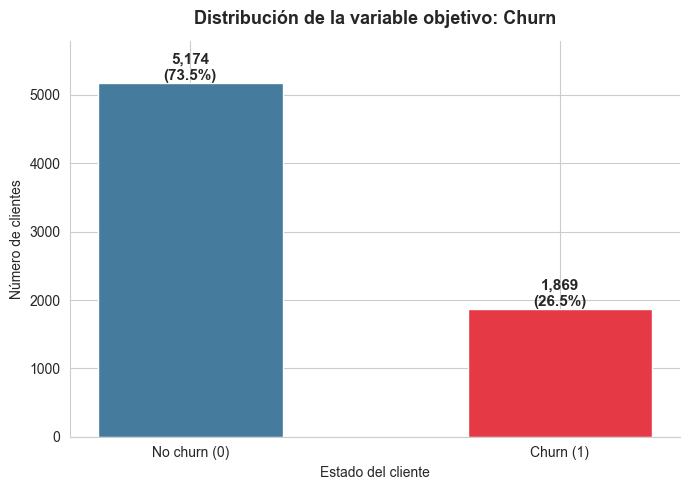

In [20]:
# Gráfico de la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(["No churn (0)", "Churn (1)"], freq.values,
              color=colors, edgecolor="white", width=0.5)

for bar, val, p in zip(bars, freq.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,}\n({p:.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Distribución de la variable objetivo: Churn", fontsize=13, pad=12)
ax.set_xlabel("Estado del cliente")
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, freq.max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La distribución de la variable objetivo muestra un **desbalance moderado**: aproximadamente el **73.5%** de los clientes permanecen con la empresa, mientras que cerca del **26.5%** la abandonan. Este desbalance no es extremo pero sí lo suficientemente notable como para justificar dos decisiones metodológicas en las etapas siguientes:

1. **Estratificar la partición train/test** por la variable `Churn`, para preservar la proporción de clases en ambos subconjuntos.
2. **Priorizar métricas más informativas que el accuracy** durante la evaluación (recall, F1, AUC), dado que un clasificador ingenuo que prediga siempre "No churn" obtendría un accuracy del 73.5%, lo que no reflejaría utilidad real.

### **1.8.2 Distribución de las variables numéricas**

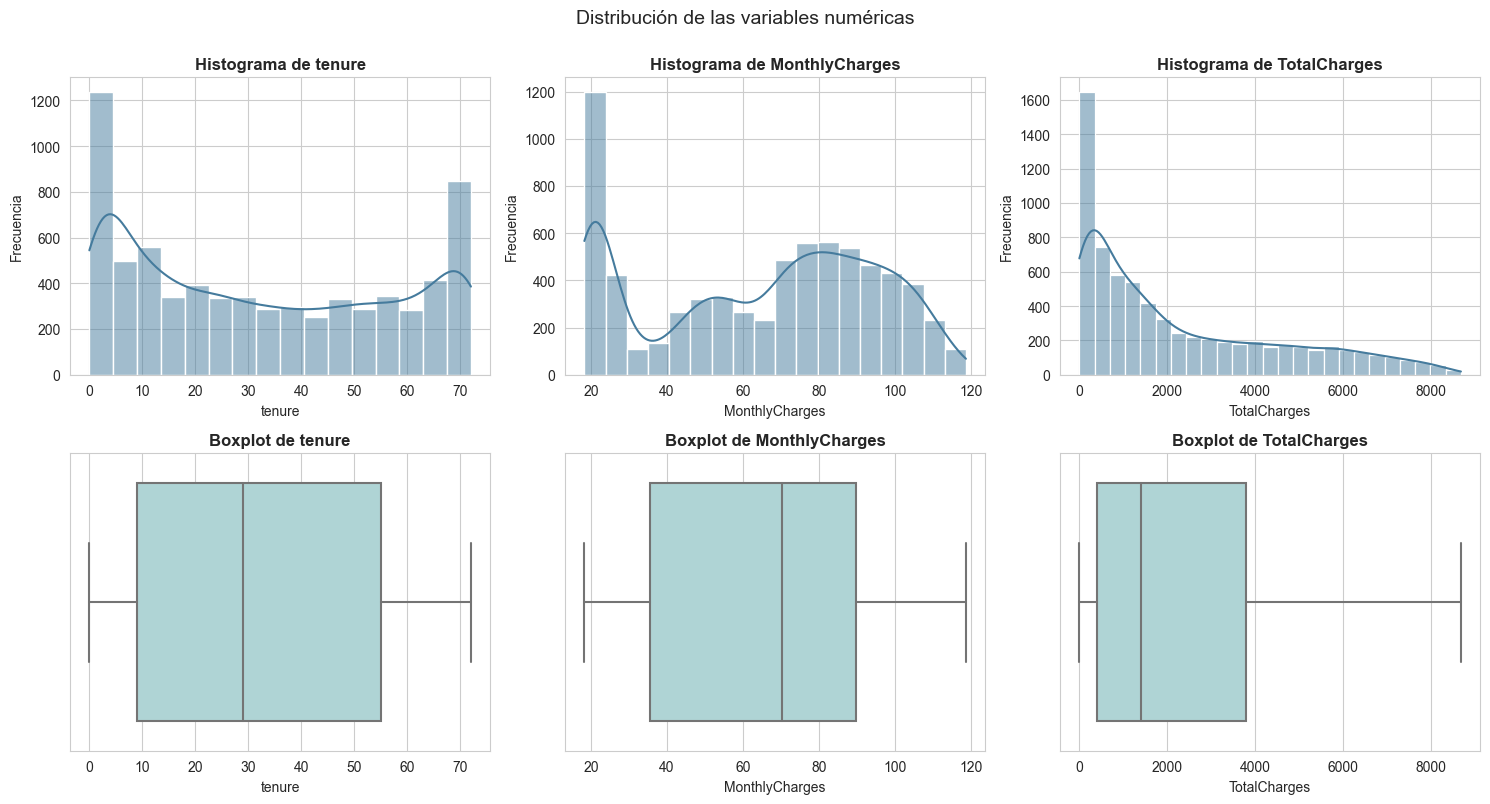

In [21]:
# Variables numéricas continuas para el análisis univariado
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribución de las variables numéricas", fontsize=14, y=1.00)

# Histogramas con KDE en la primera fila
for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=azul, edgecolor="white")
    axes[0, i].set_title(f"Histograma de {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Frecuencia")

# Boxplots en la segunda fila
for i, col in enumerate(num_vars):
    sns.boxplot(x=df[col], ax=axes[1, i], color=neutro)
    axes[1, i].set_title(f"Boxplot de {col}")
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [22]:
# Asimetría y curtosis de las variables numéricas
df[num_vars].agg(["skew", "kurt"]).round(2).rename(
    index={"skew": "Asimetría", "kurt": "Curtosis"}
)

,tenure,MonthlyCharges,TotalCharges
Asimetría,0.24,-0.22,0.96
Curtosis,-1.39,-1.26,-0.23


El análisis univariado de las tres variables numéricas continuas revela patrones distintos:

- **`tenure`** presenta una distribución **fuertemente bimodal**, con concentraciones en los extremos: muchos clientes con muy pocos meses de antigüedad y otro grupo numeroso de clientes con permanencia cercana al máximo (72 meses). Esta forma sugiere que la base de clientes está compuesta principalmente por dos perfiles: clientes nuevos en proceso de evaluación del servicio y clientes consolidados de larga data. La asimetría es moderada y la curtosis indica una distribución relativamente plana, consecuencia de la bimodalidad observada.

- **`MonthlyCharges`** exhibe una distribución **multimodal**: se observa un pico claro en valores bajos (cerca de los 20 USD, asociado probablemente a clientes con servicios mínimos) y una concentración más amplia en valores medios y altos (entre 70 y 100 USD), correspondiente a clientes con paquetes de internet y servicios adicionales. Los boxplots no muestran *outliers* clásicos definidos por el criterio del IQR, ya que los valores se distribuyen en un rango cerrado y conocido.

- **`TotalCharges`** muestra una distribución **fuertemente sesgada a la derecha**, con la mayor parte de los clientes acumulando montos relativamente bajos y una larga cola hacia los altos. Esto es esperable, dado que `TotalCharges` es una función creciente del producto `tenure × MonthlyCharges`: clientes con menor antigüedad acumulan menos cargos. La asimetría positiva confirma el sesgo y, junto con el pico cercano a 0, refleja la presencia de muchos clientes nuevos.

Ninguna de las tres variables presenta valores extremos que ameriten tratamiento especial: los aparentes *outliers* de los boxplots corresponden a casos válidos del negocio (clientes de larga permanencia y alto consumo). La estrategia adecuada es escalarlas para que tengan magnitudes comparables, lo cual se hará en el preprocesador.

## **1.9 Análisis exploratorio bivariado**

A continuación se examina la relación entre las variables predictoras y la variable objetivo `Churn`. Para variables categóricas se utilizan **gráficos de barras normalizadas**, que permiten comparar proporciones de churn entre categorías independientemente del tamaño de cada grupo. Para variables numéricas se emplean **diagramas de caja** segmentados por la clase de `Churn`.

### **1.9.1 Churn según el tipo de contrato**

In [23]:
# Tabla cruzada normalizada entre Contract y Churn
cross_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
cross_contract = cross_contract.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_contract

Churn,No churn (%),Churn (%)
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


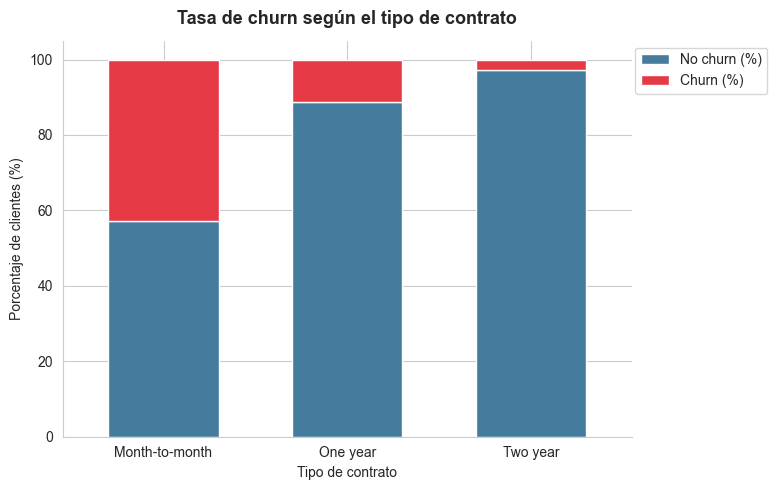

In [24]:
# Gráfico de barras apiladas normalizadas
fig, ax = plt.subplots(figsize=(8, 5))
cross_contract.plot(kind="bar", stacked=True, color=colors, ax=ax,
                    edgecolor="white", width=0.6)

ax.set_title("Tasa de churn según el tipo de contrato", fontsize=13, pad=12)
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.25, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La relación entre el tipo de contrato y el churn es una de las más marcadas del dataset:

- Los clientes con **contrato mensual (`Month-to-month`)** presentan una tasa de churn cercana al **42.7%**, varias veces superior al promedio general (26.5%).
- Los clientes con **contrato anual (`One year`)** reducen drásticamente la tasa al **11.3%**.
- Los clientes con **contrato a dos años (`Two year`)** apenas alcanzan un **2.8%** de churn.

Esto evidencia una asociación clara: a mayor compromiso contractual, menor propensión a abandonar el servicio. Se trata, sin lugar a dudas, de uno de los predictores más informativos del problema. Esta variable es candidata natural a aparecer entre las más importantes en cualquier modelo entrenado posteriormente.

### **1.9.2 Churn según el método de pago**

In [25]:
cross_payment = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
cross_payment = cross_payment.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_payment.sort_values("Churn (%)", ascending=False)

Churn,No churn (%),Churn (%)
PaymentMethod,,
Electronic check,54.71,45.29
Mailed check,80.89,19.11
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24


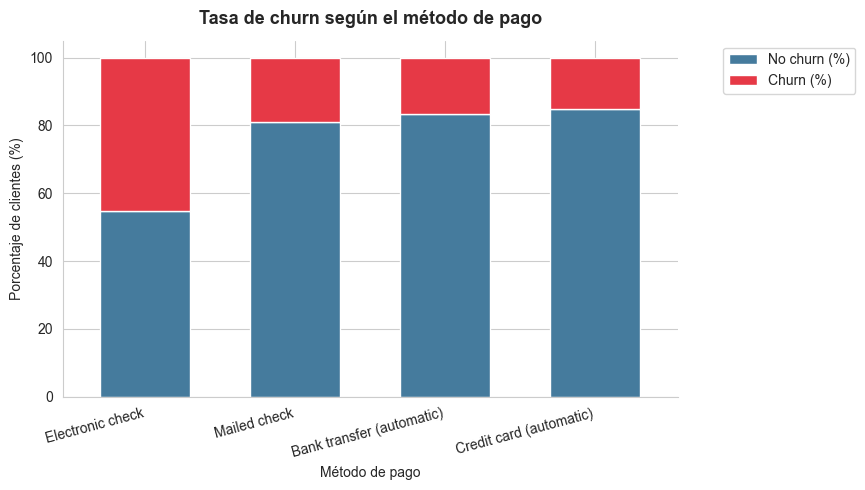

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
cross_payment.sort_values("Churn (%)", ascending=False).plot(
    kind="bar", stacked=True, color=colors, ax=ax, edgecolor="white", width=0.6
)

ax.set_title("Tasa de churn según el método de pago", fontsize=13, pad=12)
ax.set_xlabel("Método de pago")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.30, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El método de pago también muestra diferencias importantes:

- **`Electronic check`** concentra la tasa de churn más alta, superior al **45%**, lo cual la posiciona casi al doble del promedio general.
- Los métodos automáticos (**`Bank transfer (automatic)`** y **`Credit card (automatic)`**) tienen tasas notablemente más bajas, alrededor del **15-17%**.
- **`Mailed check`** se sitúa en una posición intermedia, alrededor del **19%**.

Una posible interpretación es que los clientes que utilizan métodos automatizados tienden a tener una relación más estable con la empresa (mayor compromiso, menor fricción operacional), mientras que los pagos manuales por cheque electrónico podrían correlacionarse con perfiles menos comprometidos. Conviene insistir en que se trata de **asociaciones**, no de relaciones causales.

### **1.9.3 Churn según el tipo de servicio de internet**

In [27]:
cross_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
cross_internet = cross_internet.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_internet

Churn,No churn (%),Churn (%)
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


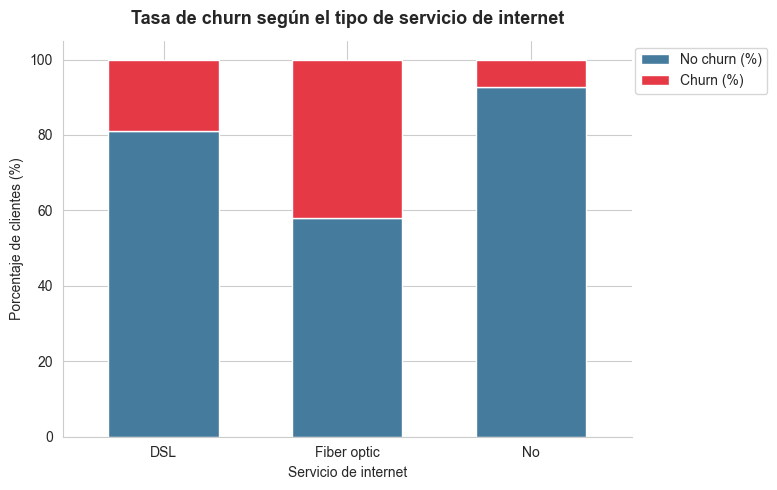

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
cross_internet.plot(kind="bar", stacked=True, color=colors, ax=ax,
                    edgecolor="white", width=0.6)

ax.set_title("Tasa de churn según el tipo de servicio de internet", fontsize=13, pad=12)
ax.set_xlabel("Servicio de internet")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.25, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La variable `InternetService` revela un patrón llamativo:

- Los clientes con **fibra óptica** son los que más abandonan el servicio (~**41.9%**), a pesar de ser el servicio teóricamente superior.
- Los clientes con **DSL** presentan una tasa intermedia (~**19.0%**).
- Quienes **no tienen servicio de internet** muestran la tasa más baja (~**7.4%**).

Este resultado, aparentemente contraintuitivo, es uno de los hallazgos más documentados en este dataset. Posibles explicaciones incluyen problemas de calidad o estabilidad del servicio de fibra, expectativas más altas en clientes que pagan más, o factores asociados a la competencia del mercado. En cualquier caso, los modelos posteriores deberán capturar adecuadamente este efecto.

### **1.9.4 Churn según `tenure`**

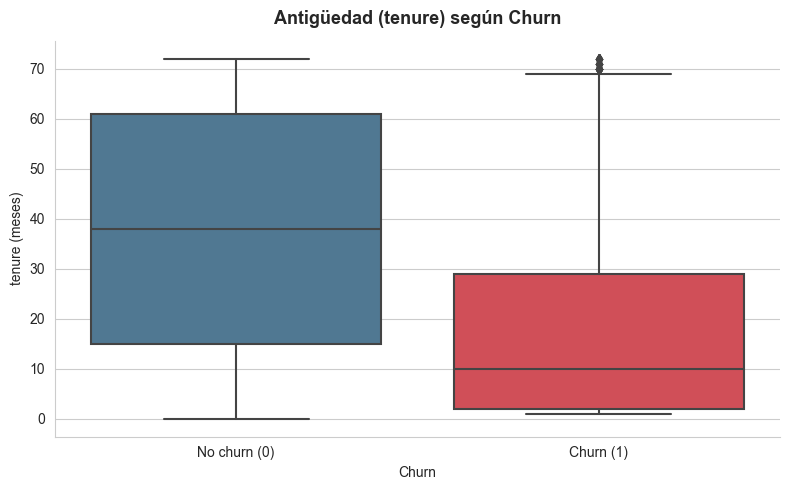

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df, palette=colors, ax=ax)

ax.set_title("Antigüedad (tenure) según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("tenure (meses)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El boxplot revela una **separación marcada** entre los dos grupos:

- Los clientes que **abandonan** (`Churn = 1`) presentan una antigüedad notablemente baja: la mediana se ubica en torno a los 10 meses y el tercer cuartil rara vez supera los 30 meses.
- Los clientes que **permanecen** (`Churn = 0`) muestran una distribución mucho más amplia, con mediana cerca de los 38 meses y un tercer cuartil próximo al máximo (72 meses).

Esta diferencia es coherente con la intuición: los clientes nuevos están en una fase de evaluación del servicio y presentan mayor riesgo de abandono, mientras que los clientes consolidados tienden a mantenerse. La variable `tenure` es, junto con `Contract`, uno de los predictores más fuertes del problema.

### **1.9.5 Churn según `MonthlyCharges`**

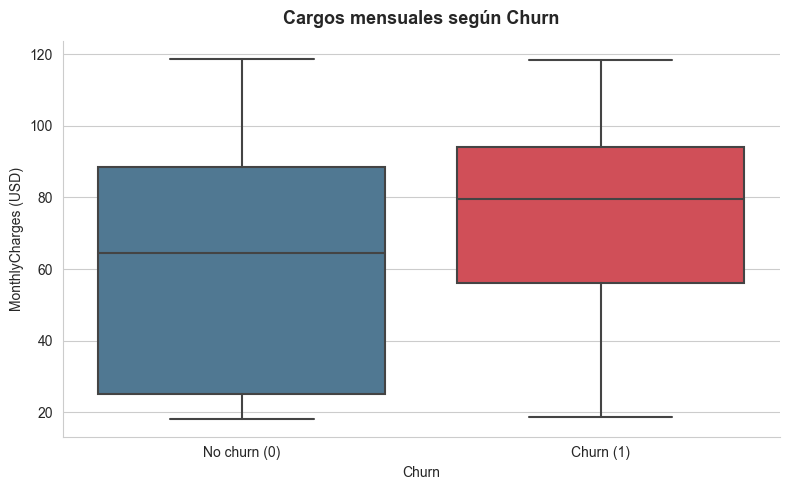

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=colors, ax=ax)

ax.set_title("Cargos mensuales según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("MonthlyCharges (USD)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Los clientes que abandonan tienden a tener **cargos mensuales más altos** que quienes se mantienen. La mediana del grupo `Churn = 1` se sitúa por encima de la del grupo `Churn = 0`, y la distribución completa se desplaza hacia valores superiores. Esto es consistente con la observación previa sobre el servicio de fibra óptica, que es el más caro y el que concentra la mayor proporción de cancelaciones. La interpretación combinada de ambas variables sugiere que los planes de mayor costo, especialmente los asociados a fibra, son los que enfrentan mayores desafíos de retención.

### **1.9.6 Churn según `TotalCharges`**

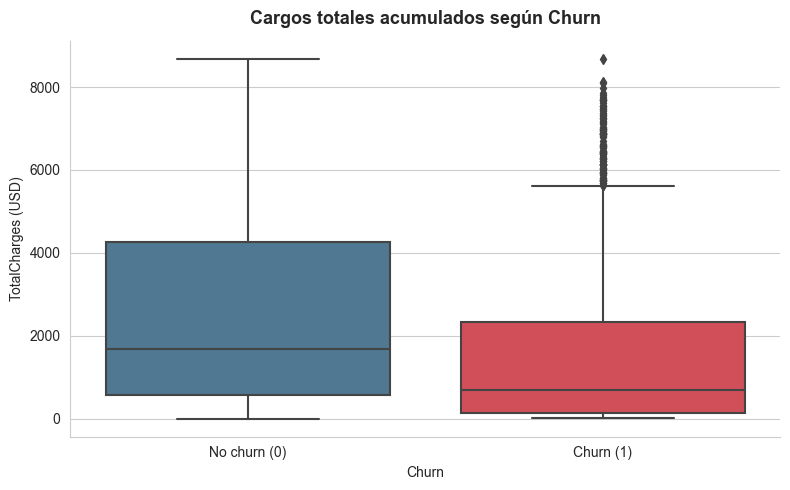

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="TotalCharges", data=df, palette=colors, ax=ax)

ax.set_title("Cargos totales acumulados según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("TotalCharges (USD)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El comportamiento de `TotalCharges` con respecto a `Churn` es consistente con el de `tenure`: los clientes que abandonan muestran montos totales acumulados **considerablemente más bajos**, dado que han pertenecido menos tiempo a la empresa y, por tanto, han acumulado menos cargos. Existe una relación natural entre `tenure`, `MonthlyCharges` y `TotalCharges` (este último es aproximadamente el producto de los otros dos), lo que se traducirá en una correlación alta entre las tres variables, fenómeno que se cuantifica en la siguiente sección.

## **1.10 Matriz de correlación**

La matriz de correlación se construye sobre las variables numéricas del dataset, junto con la variable objetivo `Churn` ya codificada como binaria. Se incluye también `SeniorCitizen`, que es numérica binaria. Para las demás variables categóricas no se calcula correlación de Pearson, pues no es la métrica adecuada para datos no ordinales; su análisis ya se abordó mediante tablas cruzadas y gráficos de barras.

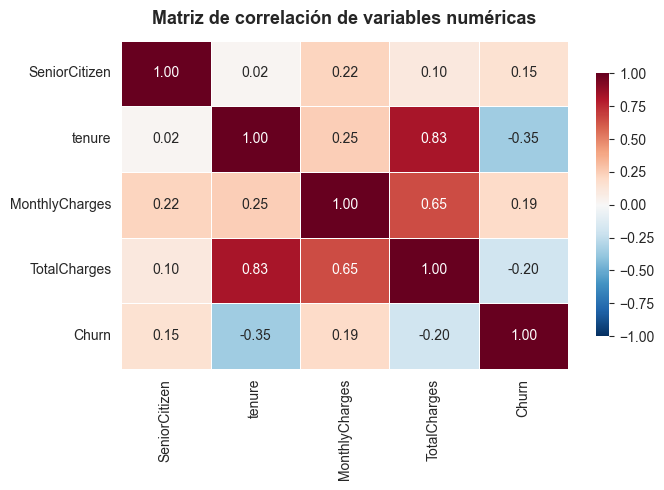

In [32]:
# Matriz de correlación con variables numéricas y binarias numéricas
vars_correlacion = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr_matrix = df[vars_correlacion].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Matriz de correlación de variables numéricas", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

La matriz de correlación resume varias observaciones importantes:

- **`tenure` y `TotalCharges`** presentan una correlación **muy alta y positiva** (≈ 0.83), lo cual era esperado, dado que `TotalCharges` se construye como una función creciente del tiempo de permanencia. Esta colinealidad no impide el modelado, pero deberá tenerse presente al interpretar la importancia de variables: ambas codifican información parcialmente redundante.

- **`MonthlyCharges` y `TotalCharges`** también muestran correlación positiva moderada (≈ 0.65), por la misma razón estructural.

- **`tenure` y `Churn`** mantienen una correlación **negativa** (≈ −0.35): a mayor antigüedad, menor probabilidad de abandono, en concordancia con el análisis bivariado anterior.

- **`MonthlyCharges` y `Churn`** muestran una correlación positiva débil (≈ 0.19), coherente con la observación de que los planes más caros tienden a tener mayores tasas de churn.

- **`SeniorCitizen` y `Churn`** exhiben una correlación positiva débil (≈ 0.15), sugiriendo que los adultos mayores tienen una tendencia ligeramente superior a abandonar el servicio.

Es importante recalcar que la **correlación no implica causalidad**: las relaciones identificadas son puramente asociativas y reflejan patrones del conjunto de datos, no relaciones causales del fenómeno de churn. Determinar causalidad requeriría diseños experimentales o cuasi-experimentales que están fuera del alcance de este proyecto.

## **1.11 Preparación inicial para modelado**

Habiendo concluido el análisis exploratorio y la limpieza, se procede a dejar el dataset listo para las siguientes secciones del proyecto. Los pasos que se ejecutan a continuación son:

1. Separación entre variables predictoras (`X`) y variable objetivo (`y`).
2. Identificación de columnas numéricas y categóricas.
3. Construcción de un **preprocesador unificado** mediante `ColumnTransformer`, que aplique:
   - **Numéricas**: imputación con la mediana + estandarización con `StandardScaler`.
   - **Categóricas**: imputación con la moda + codificación con `OneHotEncoder(handle_unknown="ignore")`.
4. Partición estratificada en entrenamiento y prueba (80/20).

Es fundamental aclarar que el preprocesador **se construye pero no se ajusta** en esta sección. El ajuste se realizará dentro de un `Pipeline` en la sección de modelado, junto con el clasificador. Esta práctica evita el llamado **data leakage**: si se imputaran o escalaran los datos antes de la partición, las estadísticas del conjunto de prueba contaminarían las del conjunto de entrenamiento, llevando a estimaciones de desempeño optimistas e irreales.

### **1.11.1 Separación de `X` e `y`**

In [33]:
# Separación entre predictores y variable objetivo
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Distribución de y: {y.value_counts(normalize=True).round(4).to_dict()}")

Dimensiones de X: (7043, 19)
Dimensiones de y: (7043,)
Distribución de y: {0: 0.7346, 1: 0.2654}


### **1.11.2 Identificación de columnas numéricas y categóricas**

Para construir el preprocesador es necesario distinguir las columnas según su naturaleza. Las columnas numéricas son `tenure`, `MonthlyCharges` y `TotalCharges`. La variable `SeniorCitizen`, aunque almacenada como entero, es conceptualmente binaria y se trata como categórica para que `OneHotEncoder` la procese de forma uniforme con el resto de variables binarias del dataset.

In [34]:
# Identificación automática
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

print(f"Columnas numéricas ({len(num_cols)}):")
for c in num_cols:
    print(f"   - {c}")

print(f"\nColumnas categóricas ({len(cat_cols)}):")
for c in cat_cols:
    print(f"   - {c}")

Columnas numéricas (3):
   - tenure
   - MonthlyCharges
   - TotalCharges

Columnas categóricas (16):
   - gender
   - SeniorCitizen
   - Partner
   - Dependents
   - PhoneService
   - MultipleLines
   - InternetService
   - OnlineSecurity
   - OnlineBackup
   - DeviceProtection
   - TechSupport
   - StreamingTV
   - StreamingMovies
   - Contract
   - PaperlessBilling
   - PaymentMethod


### **1.11.3 Construcción del preprocesador**

In [35]:
# Pipeline para variables numéricas
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer que aplica cada pipeline a su grupo correspondiente
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# lo guardamos en un archivo joblib para usarlo en el notebook de modelado
joblib.dump(preprocessor, "../app/preprocessor.joblib")

print("Preprocesador definido correctamente.")
preprocessor

Preprocesador definido correctamente.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

El `ColumnTransformer` encapsula todo el preprocesamiento en un único objeto reutilizable. Esto facilita su integración con cualquier estimador en las secciones siguientes mediante un `Pipeline` con la forma `Pipeline([("preprocessor", preprocessor), ("clf", modelo)])`, garantizando que las transformaciones se ajusten **únicamente** con los datos de entrenamiento dentro de cada *fold* de validación cruzada.

### **1.11.4 Partición estratificada en entrenamiento y prueba**

In [36]:
# Partición estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")
print(f"\nProporción de churn en entrenamiento: {y_train.mean():.4f}")
print(f"Proporción de churn en prueba:        {y_test.mean():.4f}")

# lo guardamos en archivos joblib para usarlos en el notebook de modelado
joblib.dump(X_train, "../data/X_train.joblib")
joblib.dump(X_test, "../data/X_test.joblib")
joblib.dump(y_train, "../data/y_train.joblib")
joblib.dump(y_test, "../data/y_test.joblib")

X_train: (5634, 19) | y_train: (5634,)
X_test:  (1409, 19) | y_test:  (1409,)

Proporción de churn en entrenamiento: 0.2654
Proporción de churn en prueba:        0.2654


['../data/y_test.joblib']

Se utiliza `stratify=y` para asegurar que la proporción de cada clase se preserve tanto en el conjunto de entrenamiento como en el de prueba. Esta decisión es especialmente importante en problemas de clasificación con clases desbalanceadas: sin estratificación, una partición aleatoria podría producir un conjunto de prueba con una proporción de churn significativamente distinta a la del conjunto general, comprometiendo la validez de las estimaciones de desempeño.

La salida confirma que las proporciones de churn en los dos subconjuntos son prácticamente idénticas (cerca de **26.5%** en ambos), lo cual valida la correcta aplicación de la estratificación. Se utiliza también `random_state=42` para asegurar la reproducibilidad de los resultados.

## **1.12 Conclusión parcial del análisis exploratorio**

El análisis exploratorio del dataset **Telco Customer Churn** permite extraer las siguientes conclusiones que sintetizan el estado del problema antes del modelado:

**Estado general del dataset.** El conjunto cuenta con 7 043 observaciones y 21 columnas (20 predictoras tras eliminar el identificador). El volumen es adecuado para entrenar modelos de clasificación supervisada sin requerir técnicas de muestreo especiales. Cada fila representa un cliente único, y no existen duplicados.

**Calidad de los datos.** La calidad general es alta. El único problema relevante de integridad fue la presencia de 11 cadenas vacías en `TotalCharges`, almacenadas originalmente como texto, asociadas todas ellas a clientes con `tenure = 0`. Tras convertir la variable a numérica y aplicar imputación con 0 (justificada por el hecho de que un cliente sin antigüedad no ha generado cargos acumulados), el dataset queda completamente libre de valores faltantes. No se detectaron outliers que ameriten tratamiento, ya que los valores extremos en variables como `tenure` o `MonthlyCharges` corresponden a casos válidos del negocio.

**Variables más relacionadas con el churn.** El análisis bivariado y la matriz de correlación identifican varios predictores con asociación clara con la variable objetivo:

- **`Contract`**: contratos mensuales presentan tasas de churn muy superiores (~42.7%) frente a contratos a uno (~11.3%) o dos años (~2.8%).
- **`tenure`**: a menor antigüedad, mayor probabilidad de abandono. Existe una separación visible entre las distribuciones de los dos grupos.
- **`InternetService`**: los clientes con fibra óptica muestran una tasa de churn muy elevada (~41.9%), pese a ser el servicio premium.
- **`PaymentMethod`**: el cheque electrónico se asocia a tasas de churn cercanas al 45%, considerablemente mayores que los métodos automáticos.
- **`MonthlyCharges`**: los cargos mensuales más altos están asociados a tasas de abandono superiores.

Estas asociaciones son consistentes entre sí y construyen un perfil tentativo del cliente con alta propensión al churn: cliente nuevo, con contrato mensual, servicio de fibra óptica, pago manual y cargo mensual elevado.

**Decisiones de limpieza tomadas.** Las decisiones aplicadas, todas justificadas a partir de la evidencia explorada, fueron:

1. Eliminación de la columna identificadora `customerID`.
2. Conversión de `TotalCharges` de tipo texto a numérico mediante `pd.to_numeric` con `errors="coerce"`.
3. Imputación de los 11 valores resultantes en `TotalCharges` con 0, dado que corresponden a clientes con `tenure = 0`.
4. Codificación binaria de la variable objetivo `Churn` (`Yes` = 1, `No` = 0).
5. Verificación de consistencia categórica, sin necesidad de normalizaciones adicionales.

**Preparación para las siguientes secciones.** El dataset queda particionado en conjuntos de entrenamiento (80%) y prueba (20%) mediante muestreo estratificado, preservando la proporción de la clase positiva (~26.5%) en ambos subconjuntos. Se construyó un `ColumnTransformer` que aplicará imputación con mediana y estandarización a las variables numéricas, e imputación con moda y codificación *one-hot* a las categóricas. Este preprocesador no fue ajustado en esta sección, sino que se entrega listo para integrarse dentro de un `Pipeline` en la sección de modelado, garantizando un flujo libre de *data leakage*. Con esto, las siguientes etapas del proyecto pueden proceder sobre un cimiento sólido y reproducible.